# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import pickle


# Loading the Dataset and Basic Data cleaning

In [2]:
df=pd.read_csv("cardio_train.csv",sep=";")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# 3. BASIC CLEANING
# ==============================
# Drop ID
df.drop(columns=['id'], inplace=True)

# Convert age from days to years
df['age'] = df['age'] / 365

# Remove unrealistic values (important for project quality)
df = df[(df['ap_hi'] < 250) & (df['ap_lo'] < 200)]
df = df[(df['ap_hi'] > 50) & (df['ap_lo'] > 30)]

# Filter Height (130-220 cm) and Weight (40-180 kg)
df = df[(df['height'] >= 130) & (df['height'] <= 220)]
df = df[(df['weight'] >= 40) & (df['weight'] <= 180)]

# 4. FEATURE ENGINEERING
# BMI is a stronger health indicator than weight alone
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
df.drop(columns=['weight','height'],inplace=True)

In [4]:
#Statistical summary of the data
df.describe()

,age,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
count,68636.000000,68636.000000,68636.000000,68636.000000,68636.000000,68636.000000,68636.000000,68636.000000,68636.000000,68636.000000,68636.000000
mean,53.327558,1.348855,126.625794,81.388805,1.364954,1.226062,0.088073,0.053660,0.803412,0.495017,27.449007
std,6.761574,0.476611,16.758033,9.674378,0.679126,0.572027,0.283404,0.225347,0.397421,0.499979,5.195338
min,29.583562,1.000000,60.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,13.520822
25%,48.377397,1.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,23.875115
50%,53.975342,1.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,26.346494
75%,58.421918,2.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,30.116213
max,64.967123,2.000000,240.000000,190.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,85.779743


In [5]:
#Checking the datatypes of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68636 entries, 0 to 69999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          68636 non-null  float64
 1   gender       68636 non-null  int64  
 2   ap_hi        68636 non-null  int64  
 3   ap_lo        68636 non-null  int64  
 4   cholesterol  68636 non-null  int64  
 5   gluc         68636 non-null  int64  
 6   smoke        68636 non-null  int64  
 7   alco         68636 non-null  int64  
 8   active       68636 non-null  int64  
 9   cardio       68636 non-null  int64  
 10  bmi          68636 non-null  float64
dtypes: float64(2), int64(9)
memory usage: 6.3 MB


# Exploratory Data Analysis (EDA)

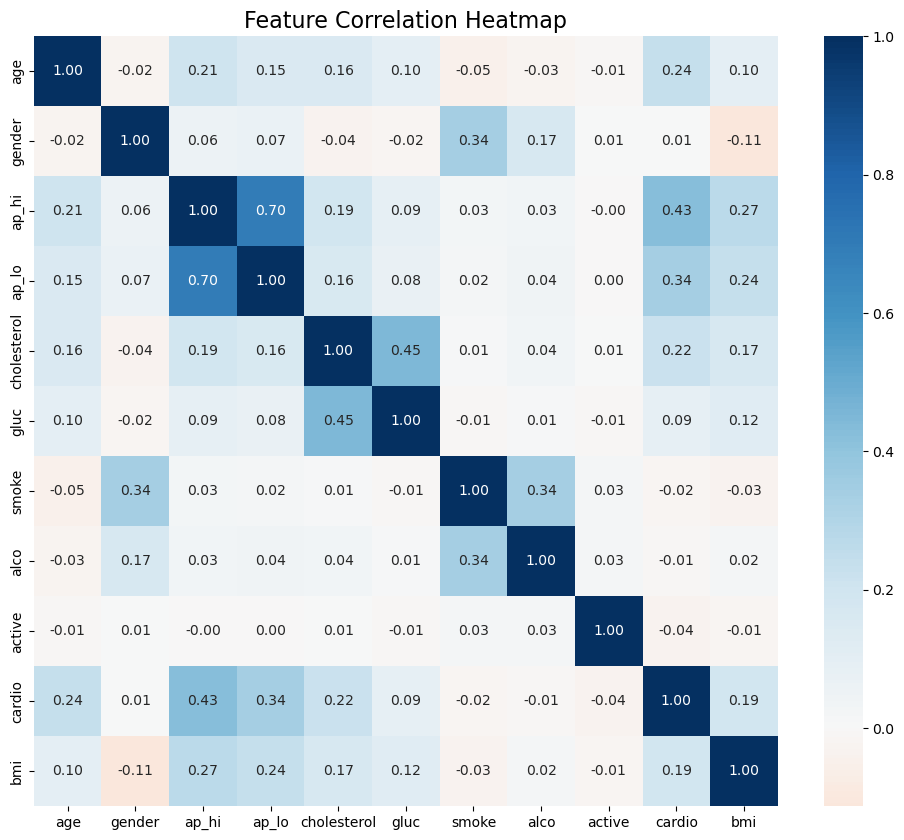

----  Correlation Heatmap Summary  ----

Blood Pressure Dominates:
Systolic (ap_hi) and Diastolic (ap_lo) are the strongest predictors of cardiovascular disease, showing the highest positive 
correlations with the target.

Major Risk Factors:
Age and Cholesterol have significant positive relationships with heart disease, indicating that risk increases notably as these values rise.

Metabolic Connection:
A moderate correlation between cholesterol and glucose suggests that metabolic disorders often occur together and may jointly increase risk.

Lifestyle Factors:
Variables like smoking, alcohol consumption, and physical activity show very weak correlations, possibly due to under-reporting 
or indirect effects already reflected in clinical measures like blood pressure.


In [6]:
# A. Correlation Heatmap (Multivariate Analysis)
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='RdBu', fmt=".2f", center=0)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

print("----  Correlation Heatmap Summary  ----")
print("\nBlood Pressure Dominates:\nSystolic (ap_hi) and Diastolic (ap_lo) are the strongest predictors of cardiovascular disease, showing the highest positive \ncorrelations with the target.")
print("\nMajor Risk Factors:\nAge and Cholesterol have significant positive relationships with heart disease, indicating that risk increases notably as these values rise.")
print("\nMetabolic Connection:\nA moderate correlation between cholesterol and glucose suggests that metabolic disorders often occur together and may jointly increase risk.")
print("\nLifestyle Factors:\nVariables like smoking, alcohol consumption, and physical activity show very weak correlations, possibly due to under-reporting \nor indirect effects already reflected in clinical measures like blood pressure.")

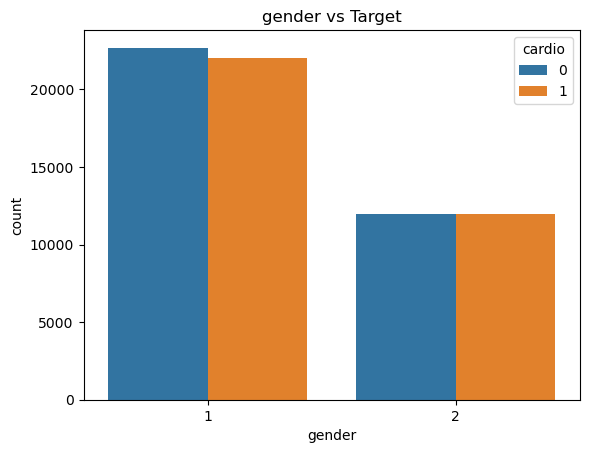

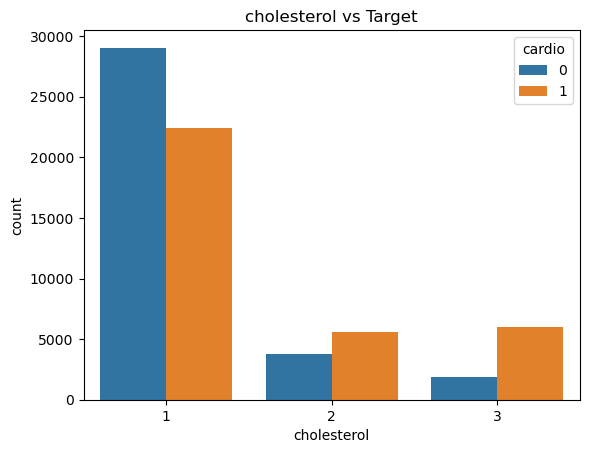

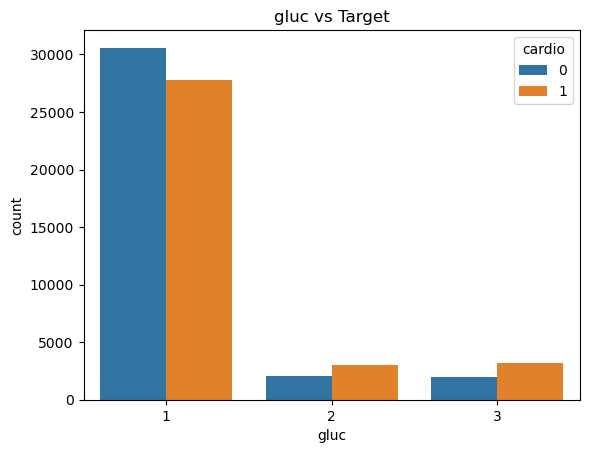

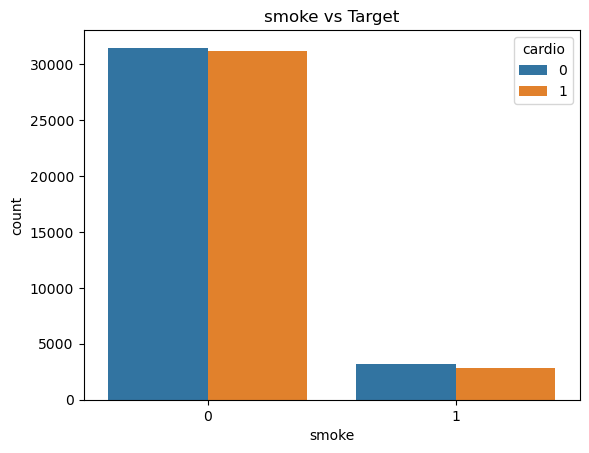

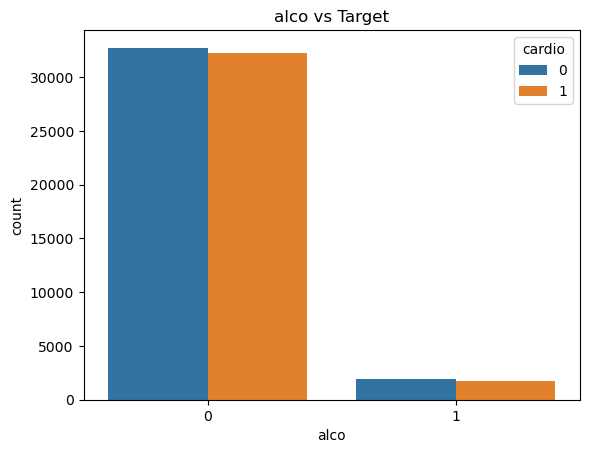

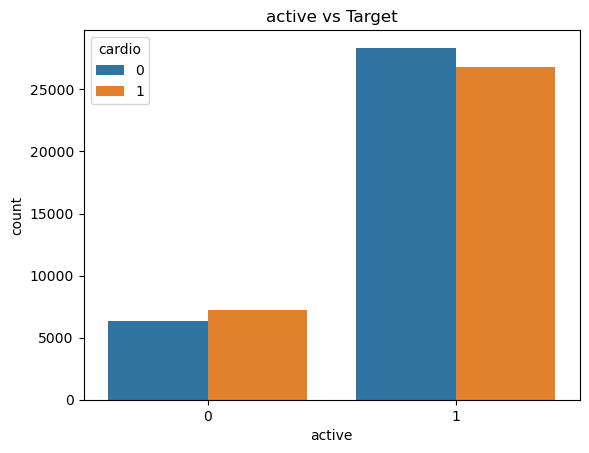

In [7]:
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

for col in cat_cols:
    sns.countplot(x=col, hue='cardio', data=df)
    plt.title(f"{col} vs Target")
    plt.show()

C:\Users\Shivraj\AppData\Local\Temp\ipykernel_1976\2911539985.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_risk = df.groupby('age_bin')['cardio'].mean()


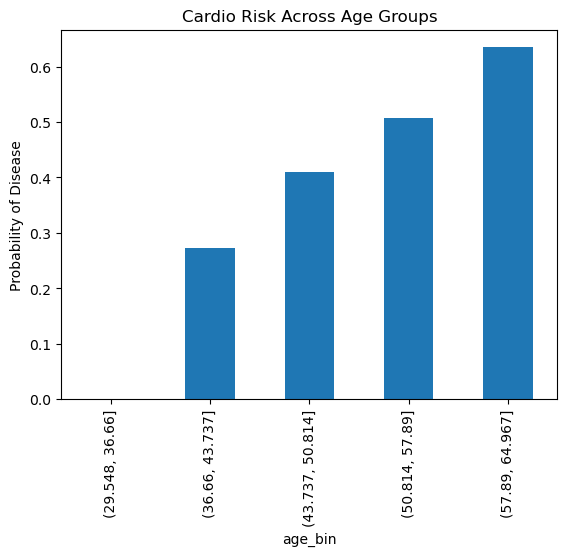


----- 1. Binning Plot Summary -----

The plot shows a non-linear increase in cardiovascular risk with age, where risk rises sharply in higher age groups rather than gradually.
This indicates that age acts as a threshold-based risk factor, making older populations significantly more vulnerable.


In [8]:
#Bar plot of Age vs cardio risk probability
df['age_bin'] = pd.cut(df['age'], bins=5)

age_risk = df.groupby('age_bin')['cardio'].mean()

age_risk.plot(kind='bar', title="Cardio Risk Across Age Groups")
plt.ylabel("Probability of Disease")
plt.show()
print("\n----- 1. Binning Plot Summary -----")
print("\nThe plot shows a non-linear increase in cardiovascular risk with age, where risk rises sharply in higher age groups rather than gradually.")
print("This indicates that age acts as a threshold-based risk factor, making older populations significantly more vulnerable.")

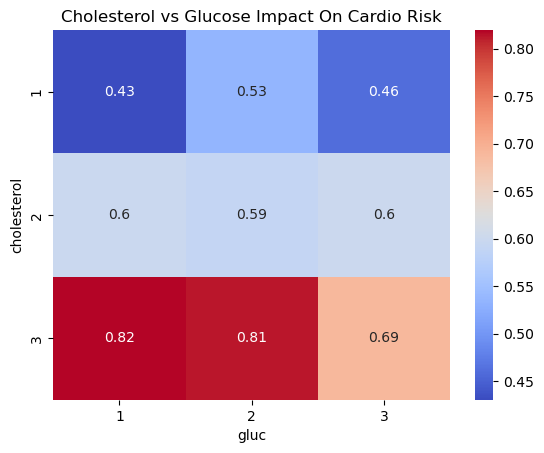


-----2. Cholesterol vs Glucose Heatmap (Interaction Plot) Summmary -----

The heatmap reveals that individuals with both high cholesterol and high glucose levels exhibit the highest cardiovascular risk.
This highlights a compounded metabolic effect, where combined abnormalities significantly amplify disease probability.


In [9]:
#2. Cholesterol vs Glucose Heatmap (Interaction Plot)
pivot = pd.pivot_table(
    df, 
    values='cardio', 
    index='cholesterol', 
    columns='gluc', 
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title("Cholesterol vs Glucose Impact On Cardio Risk")
plt.show()
print("\n-----2. Cholesterol vs Glucose Heatmap (Interaction Plot) Summmary -----")
print("\nThe heatmap reveals that individuals with both high cholesterol and high glucose levels exhibit the highest cardiovascular risk.")
print("This highlights a compounded metabolic effect, where combined abnormalities significantly amplify disease probability.")


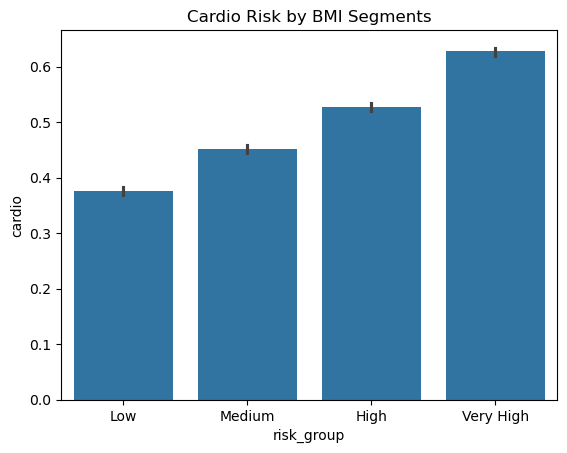


----- 3. BMI Risk Segmentation Plot Summary -----

Cardiovascular risk increases progressively across BMI categories, with the highest risk observed in the “Very High” BMI group.
This confirms that BMI is an effective composite indicator of health risk compared to height and weight individually.


In [10]:
#3. BMI Risk Segmentation Plot
df['risk_group'] = pd.qcut(df['bmi'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

sns.barplot(x='risk_group', y='cardio', data=df)
plt.title("Cardio Risk by BMI Segments")
plt.show()
print("\n----- 3. BMI Risk Segmentation Plot Summary -----")
print("\nCardiovascular risk increases progressively across BMI categories, with the highest risk observed in the “Very High” BMI group.")
print("This confirms that BMI is an effective composite indicator of health risk compared to height and weight individually.")

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['age','ap_hi','ap_lo','bmi']]

vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)
print("\n----- Multicollinearity (VIF) Analysis Summary -----")
print("The VIF values indicate severe multicollinearity among the features, particularly for ap_hi (116.86) and ap_lo (121.81), suggesting a very \nstrong linear relationship between systolic and diastolic blood pressure.")

  Feature         VIF
0     age   45.653506
1   ap_hi  116.861504
2   ap_lo  121.811690
3     bmi   29.527368

----- Multicollinearity (VIF) Analysis Summary -----
The VIF values indicate severe multicollinearity among the features, particularly for ap_hi (116.86) and ap_lo (121.81), suggesting a very 
strong linear relationship between systolic and diastolic blood pressure.


# Statistical Tests 

In [12]:
#T-test for numerical columns (To check whether the mean of a feature differs between two groups:)
from scipy.stats import ttest_ind
num_cols = ['age','bmi', 'ap_hi', 'ap_lo']
group0 = df[df['cardio']==0]
group1 = df[df['cardio']==1]

for col in num_cols:
    stat, p = ttest_ind(group0[col], group1[col])
    print(f"{col}: p-value = {p}")
print("\n\nAll features (age, BMI, ap_hi, ap_lo) have p-values < 0.05, indicating statistical significance.")
print("There is a clear difference between patients with and without cardiovascular disease.")
print("The null hypothesis is rejected for all variables.")
print("Blood pressure and age are strong clinical risk factors.")
print("Overall, these features significantly impact disease prediction.")


age: p-value = 0.0
bmi: p-value = 0.0
ap_hi: p-value = 0.0
ap_lo: p-value = 0.0


All features (age, BMI, ap_hi, ap_lo) have p-values < 0.05, indicating statistical significance.
There is a clear difference between patients with and without cardiovascular disease.
The null hypothesis is rejected for all variables.
Blood pressure and age are strong clinical risk factors.
Overall, these features significantly impact disease prediction.


In [13]:
#Chi square for independence of attributes (To check whether a feature is associated with the target variable)
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
from scipy.stats import chi2_contingency

cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

for col in cat_cols:
    contingency = pd.crosstab(df[col], df['cardio'])
    chi2, p, _, _ = chi2_contingency(contingency)
    print(f"{col}: p-value = {p}")

print("""
All categorical features except gender show p-values less than 0.05, indicating statistical significance.
Cholesterol and glucose have extremely low p-values, making them the strongest associated factors.
Smoking, alcohol consumption, and physical activity also show significant relationships with the target variable.
Gender has a p-value greater than 0.05, suggesting no strong association with cardiovascular disease.
Overall, most categorical variables significantly influence the likelihood of cardiovascular disease.
""")

gender: p-value = 0.06591141850578063
cholesterol: p-value = 0.0
gluc: p-value = 3.059129596283506e-127
smoke: p-value = 1.86926624185284e-05
alco: p-value = 0.03674676028562838
active: p-value = 1.6200599358287234e-22

All categorical features except gender show p-values less than 0.05, indicating statistical significance.
Cholesterol and glucose have extremely low p-values, making them the strongest associated factors.
Smoking, alcohol consumption, and physical activity also show significant relationships with the target variable.
Gender has a p-value greater than 0.05, suggesting no strong association with cardiovascular disease.
Overall, most categorical variables significantly influence the likelihood of cardiovascular disease.



# Feature Selection Based On EDA 

In [14]:
# Drop less useful / high multicollinearity feature
X = df.drop(['cardio', 'ap_lo', 'age_bin', 'risk_group'], axis=1, errors='ignore')
y = df['cardio']

# Train Test Split

In [15]:
#Train test splitting the data into 80% train and 20% test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
#Scaling for logistic regression model
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Building 

In [17]:
#logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Model
lr = LogisticRegression(max_iter=1000)

# Train (use scaled data)
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7226835664335665


# Decision Tree

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Base model
dt = DecisionTreeClassifier(random_state=42)

# Parameter grid
param_grid_dt = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Grid Search
grid_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid_dt.fit(X_train, y_train)

# Best model
best_dt = grid_dt.best_estimator_

print("Best DT Params:", grid_dt.best_params_)
print("Best CV Score:", grid_dt.best_score_)

Best DT Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV Score: 0.7301669155430927


In [27]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Model
dt = DecisionTreeClassifier(criterion='entropy',
    max_depth=5,
    min_samples_leaf=4,
    min_samples_split=2,
    random_state=42)

# Train
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7219551282051282


# Random Forest 

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print("Best RF Params:", grid_rf.best_params_)
print("Best RF Score:", grid_rf.best_score_)

Best RF Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RF Score: 0.7357216261763817


In [24]:
#Random forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Model
rf = RandomForestClassifier(max_depth=10,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=200,
    random_state=42)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7246503496503497


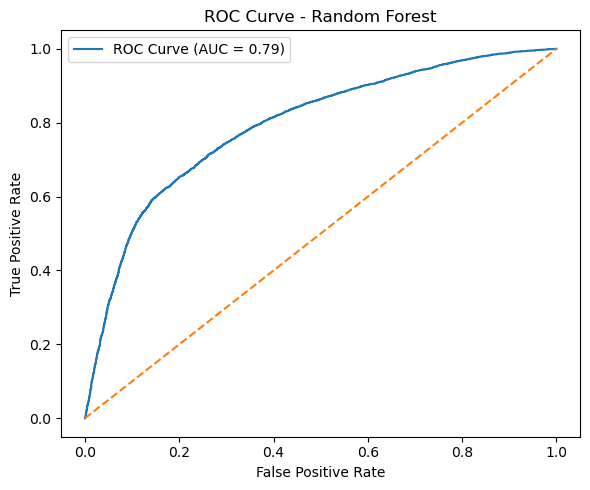


The ROC curve shows the trade-off between true positive rate and false positive rate.
The model achieves a good AUC score, indicating strong classification performance.
The curve staying above the diagonal line confirms that the model performs better than random guessing.



In [33]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = rf.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--')  # Random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.tight_layout()
plt.show()

print("""
The ROC curve shows the trade-off between true positive rate and false positive rate.
The model achieves a good AUC score, indicating strong classification performance.
The curve staying above the diagonal line confirms that the model performs better than random guessing.
""")

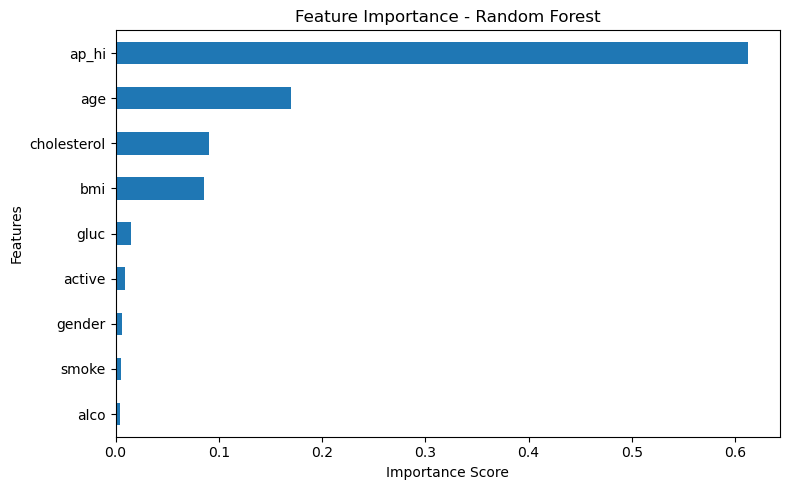

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Get importance
importances = rf.feature_importances_

# Create DataFrame
feat_imp = pd.Series(importances, index=X_train.columns)

# Sort
feat_imp = feat_imp.sort_values()

# Plot
plt.figure(figsize=(8,5))
feat_imp.plot(kind='barh')

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

# XG boost

In [21]:
#xg boost clasifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Model
xgb = XGBClassifier(eval_metric='logloss')

# Train
xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test)

# Accuracy
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.722465034965035


# Comparing the models 

In [29]:
from sklearn.metrics import accuracy_score

# Logistic Regression
train_lr = accuracy_score(y_train, lr.predict(X_train_scaled))
test_lr = accuracy_score(y_test, lr.predict(X_test_scaled))

# Decision Tree
train_dt = accuracy_score(y_train, dt.predict(X_train))
test_dt = accuracy_score(y_test, dt.predict(X_test))

# Random Forest
train_rf = accuracy_score(y_train, rf.predict(X_train))
test_rf = accuracy_score(y_test, rf.predict(X_test))

# XGBoost
train_xgb = accuracy_score(y_train, xgb.predict(X_train))
test_xgb = accuracy_score(y_test, xgb.predict(X_test))

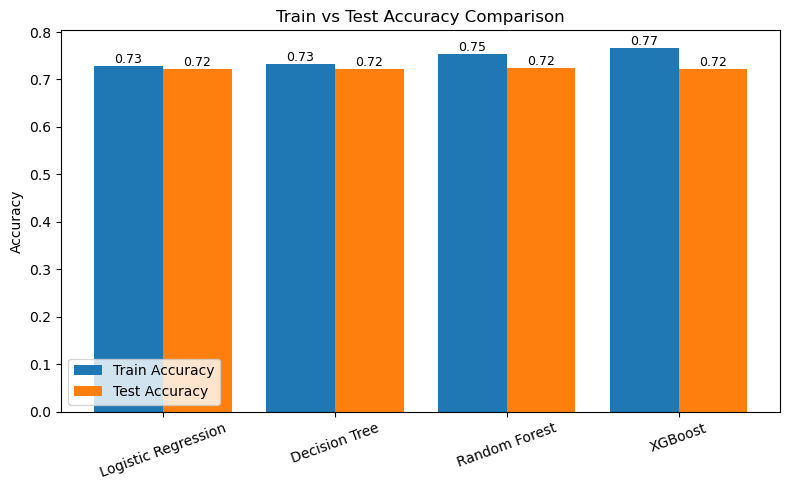

In [31]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

train_acc = [train_lr, train_dt, train_rf, train_xgb]
test_acc = [test_lr, test_dt, test_rf, test_xgb]

x = np.arange(len(models))

plt.figure(figsize=(8,5))

bars1 = plt.bar(x - 0.2, train_acc, width=0.4, label='Train Accuracy')
bars2 = plt.bar(x + 0.2, test_acc, width=0.4, label='Test Accuracy')

# 🔥 ADD LABELS ON BARS
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# Labels & Title
plt.xticks(x, models, rotation=20)
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy Comparison")
plt.legend()

plt.tight_layout()
plt.show()

# Final Conclusion

All models achieved similar test accuracy (~0.72), indicating comparable predictive performance.
Logistic Regression showed the most stable performance with minimal overfitting.
Decision Tree did not provide additional benefit despite tuning.
Random Forest and XGBoost showed higher training accuracy but slight overfitting.
Overall, Random Forest is preferred due to its ability to capture complex patterns while maintaining reasonable generalization.


In [ ]:
import pickle

# Save model
with open("cardio_rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("Model saved successfully!")